In [1]:

import xrfclk
from pynq import Overlay, allocate
import numpy as np
import time
import matplotlib.pyplot as plt
xrfclk.set_ref_clks()#lmk=122.88, lmx=409.6

#Configuration

FRAME_SAMPLES = 256

ol = Overlay("top_design.bit")

BITSTREAM = "top_design.bit"   # Change if required
DMA_NAME = "axi_dma_0"         # Change to the DMA name in your overlay

FS_OUT = 10e6                    # Final complex sample rate after decimation
FRAME_SAMPLES = 256#1028            # uint32 IQ words per DMA frame                 # Number of frames to capture

ADC_INPUT_FREQ = 1091e6
NCO_FREQ = -1090e6
EXPECTED_BASEBAND = ADC_INPUT_FREQ + NCO_FREQ

print(f"Expected baseband tone: {EXPECTED_BASEBAND/1e6:.3f} MHz")

print("Available IP:")
for name in ol.ip_dict.keys():
    print("  ", name)

dma = getattr(ol, DMA_NAME)


print(f"\nUsing DMA: {DMA_NAME}")

Expected baseband tone: 1.000 MHz
Available IP:
   axi_dma_0
   rfdc
   zynq_ultra_ps_e_0

Using DMA: axi_dma_0


In [39]:
rx_buffer = allocate(
    shape=(FRAME_SAMPLES,),
    dtype=np.uint32
)
dma.recvchannel.transfer(rx_buffer)
dma.recvchannel.wait()

packed = np.asarray(rx_buffer, dtype=np.uint32)

#print(f"\nTotal packed IQ samples: {len(packed):,}")
#print(f"Capture duration: {len(packed)/FS_OUT*1e3:.3f} ms")

q_u16 = ((packed >> 16) & 0xFFFF).astype(np.uint16)
i_u16 = (packed & 0xFFFF).astype(np.uint16)

I = i_u16.view(np.int16)
Q = q_u16.view(np.int16)

x = I.astype(np.float64) + 1j * Q.astype(np.float64)

# print("First 10 packed words / unpacked samples:")
# for k in range(min(10, len(packed))):
#     print(f"{k:2d}: 0x{int(packed[k]):08X}  I={int(I[k]):6d}  Q={int(Q[k]):6d}")

print(f"\nI range: {I.min()} to {I.max()}")
print(f"Q range: {Q.min()} to {Q.max()}")

N = len(x)
window = np.hanning(N)

X = np.fft.fftshift(np.fft.fft(x * window)) / np.sum(window)
f = np.fft.fftshift(np.fft.fftfreq(N, d=1/FS_OUT))

mag_dbfs = 20 * np.log10(np.maximum(np.abs(X) / 32768.0, 1e-15))

peak_idx = np.argmax(mag_dbfs)
peak_freq = f[peak_idx]
peak_level = mag_dbfs[peak_idx]

rx_buffer.freebuffer()

print(f"FFT size: {N:,}")
print(f"Frequency resolution: {FS_OUT/N:.1f} Hz")
print(f"Peak frequency: {peak_freq/1e6:.6f} MHz")
print(f"Peak level: {peak_level:.2f} dBFS")
print(f"Expected frequency: {EXPECTED_BASEBAND/1e6:.6f} MHz")


I range: -690 to 706
Q range: -701 to 703
FFT size: 256
Frequency resolution: 39062.5 Hz
Peak frequency: -1.992188 MHz
Peak level: -33.73 dBFS
Expected frequency: 1.000000 MHz


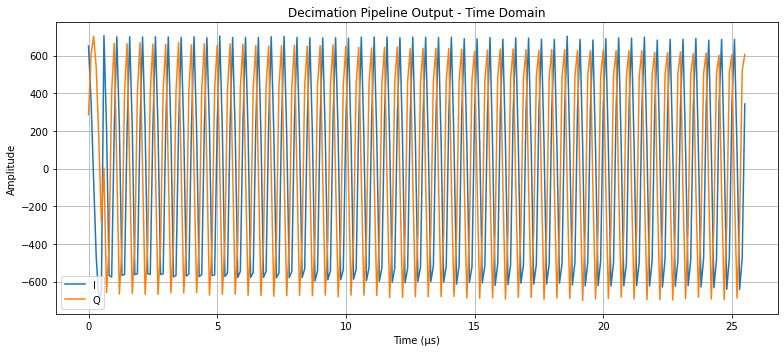

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


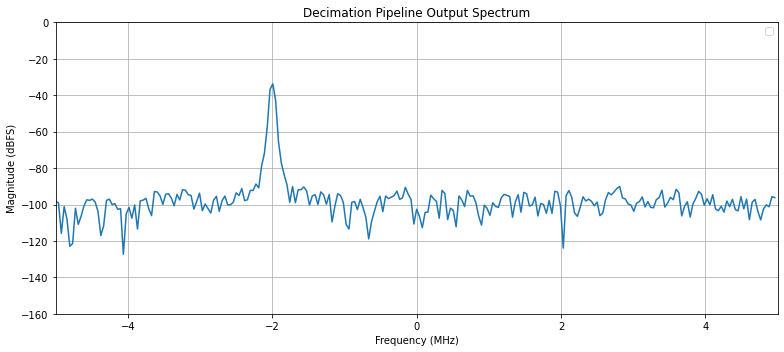

In [40]:
#Time domain
# ============================================================
t_out = np.arange(N) /FS_OUT
plt.figure(figsize=(11, 5))

plt.plot(
    t_out * 1e6,
    I,
    label="I"
)

plt.plot(
    t_out * 1e6,
    Q,
    label="Q"
)


plt.xlabel("Time (µs)")
plt.ylabel("Amplitude")
plt.legend()
plt.title("Decimation Pipeline Output - Time Domain")
plt.grid(True)

plt.tight_layout()
plt.show()

#Frequency domain
plt.figure(figsize=(11, 5))
plt.plot(f / 1e6, mag_dbfs)
#plt.axvline(EXPECTED_BASEBAND / 1e6, linestyle="--", label="Expected +2 MHz")
plt.grid(True)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dBFS)")
plt.title("Decimation Pipeline Output Spectrum")
plt.ylim(-160, 0)
plt.xlim(-FS_OUT / 2e6, FS_OUT / 2e6)
plt.legend()
plt.tight_layout()
plt.show()